📝 Project Overview: Customer Segmentation AnalysisThis project performs data-driven customer segmentation for an e-commerce platform using the ifood_df.csv dataset. By executing an end-to-end data analytics workflow—including data cleaning, descriptive statistical profiling, and K-Means Clustering ($K=4$)—the analysis uncovers distinct behavioral patterns based on customer income and purchasing habits across product categories (wines, meats, fruits, sweets, and fish).

Load and Explore the Data



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('/content/ifood_df.csv')

# Display basic information and the first few rows
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


Data Cleaning and Preprocessing

In [2]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values or fill them if necessary
# df = df.dropna()

# Select relevant columns for behavioral segmentation
# (e.g., spending columns, number of purchases, recency, etc.)
# Update these column names based on df.columns output from Step 1
features = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'Income']
X = df[features]

# Handle potential scaling issues using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

Find the Optimal Number of Clusters ($K$)

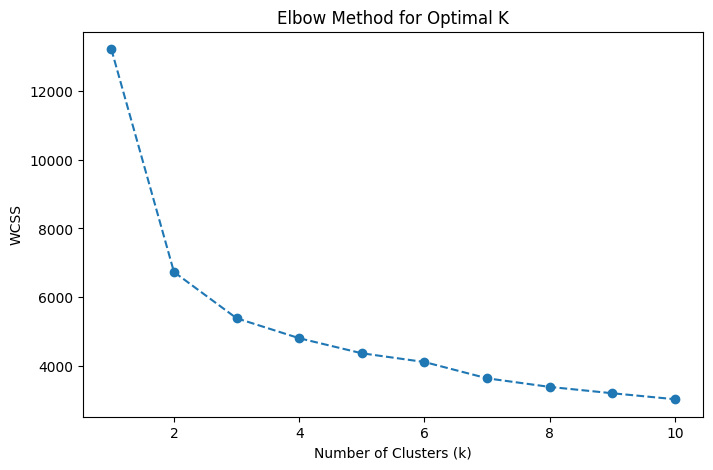

In [3]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

Apply K-Means Clustering

In [4]:
# Apply K-means
optimal_k = 4  # Adjust this based on your Elbow plot results
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View how many customers fall into each segment
print(df['Cluster'].value_counts())

Cluster
1    1192
3     515
2     266
0     232
Name: count, dtype: int64


Visualize and Analyze the Segments

           MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                            
0        695.698276  60.081897       650.448276       102.517241   
1         70.383389   5.605705        30.924497         8.463926   
2        454.503759  95.139098       307.733083       120.962406   
3        599.798058  23.866019       184.252427        33.405825   

         MntSweetProducts        Income  
Cluster                                  
0               56.900862  78962.456897  
1                5.599832  36107.776007  
2               99.909774  70736.274436  
3               25.953398  65341.963107  


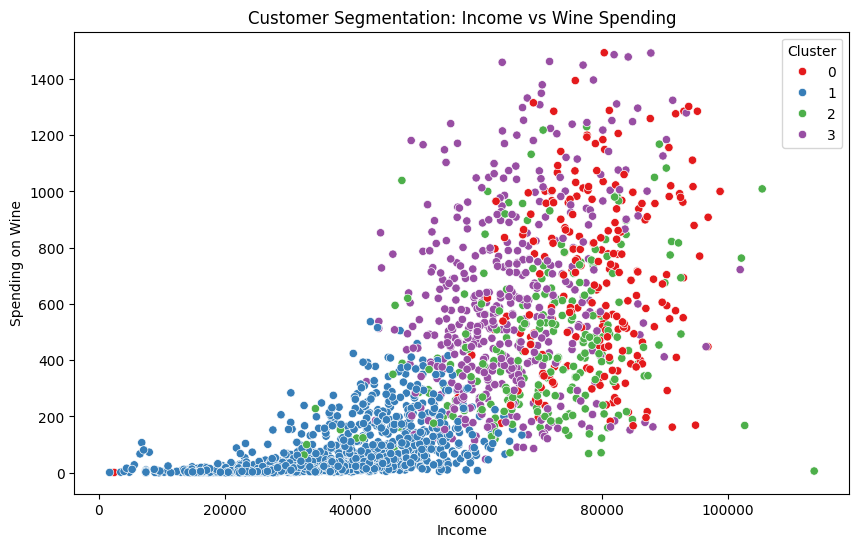

In [5]:
# Calculate the mean value of each feature per cluster
cluster_profile = df.groupby('Cluster')[features].mean()
print(cluster_profile)

# Simple scatter plot visualization (e.g., Income vs. Wine Spending)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='MntWines', hue='Cluster', palette='Set1')
plt.title('Customer Segmentation: Income vs Wine Spending')
plt.xlabel('Income')
plt.ylabel('Spending on Wine')
plt.legend(title='Cluster')
plt.show()

Descriptive Statistics

In [6]:
# 1. Calculate overall key metrics for the entire dataset
print("--- Overall Descriptive Statistics ---")

# Average total spending (MntTotal) and Income
avg_income = df['Income'].mean()
avg_total_spend = df['MntTotal'].mean()

print(f"Average Customer Income: ${avg_income:,.2f}")
print(f"Average Total Spending: ${avg_total_spend:,.2f}")

# Average frequency of purchases across channels
purchase_channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
print("\nAverage Number of Purchases by Channel:")
print(df[purchase_channels].mean())

# Summary statistics for all spending categories
df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts']].describe()

--- Overall Descriptive Statistics ---
Average Customer Income: $51,622.09
Average Total Spending: $562.76

Average Number of Purchases by Channel:
NumWebPurchases        4.100680
NumCatalogPurchases    2.645351
NumStorePurchases      5.823583
dtype: float64


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,306.164626,26.403175,165.312018,37.756463,27.128345
std,337.493839,39.784484,217.784507,54.824635,41.130468
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,2.000000,16.000000,3.000000,1.000000
50%,178.000000,8.000000,68.000000,12.000000,8.000000
75%,507.000000,33.000000,232.000000,50.000000,34.000000
max,1493.000000,199.000000,1725.000000,259.000000,262.000000


Bar Chart Visualization

/tmp/ipykernel_352/3425630461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='Set2')


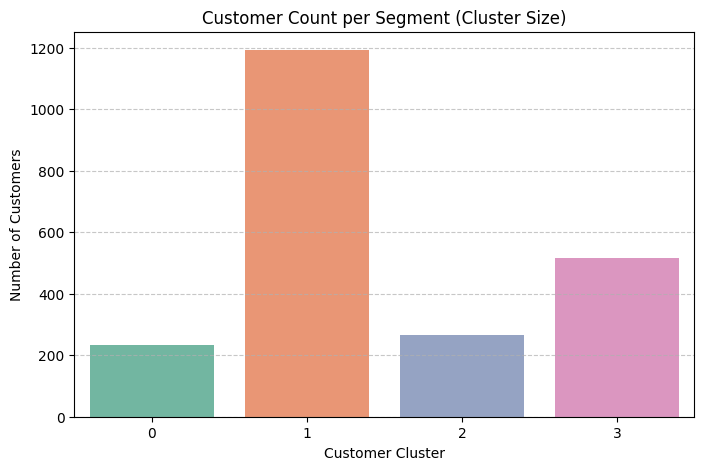

/tmp/ipykernel_352/3425630461.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Cluster', y='Income', palette='Set2', errorbar=None)


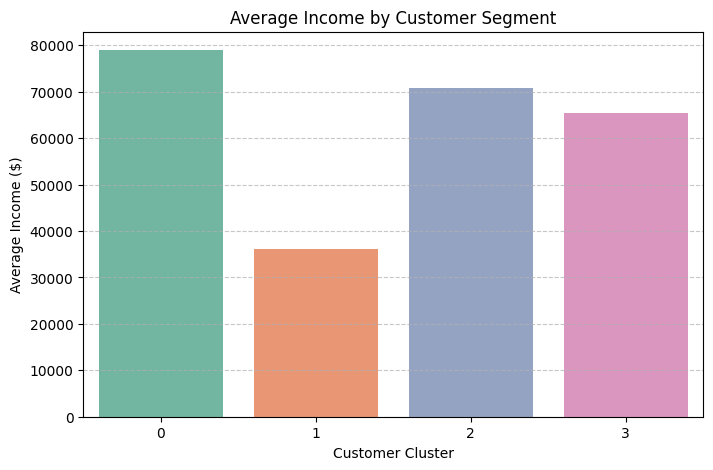

In [7]:
# 2. Bar Chart: Visualizing the size of each customer segment
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Cluster', palette='Set2')
plt.title('Customer Count per Segment (Cluster Size)')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Bar Chart: Comparing Average Income across clusters
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Cluster', y='Income', palette='Set2', errorbar=None)
plt.title('Average Income by Customer Segment')
plt.xlabel('Customer Cluster')
plt.ylabel('Average Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()